# Merge

In [2]:
import pandas as pd
import os
import numpy as np

# =========================
# 전처리 파일 불러오기
# =========================

file_map = {
    'month': 'month2.csv',
    'year': 'year2.csv',
    'age': 'age2.csv',
    'job': 'job2.csv',
    'region': 'region2.csv',
    'stock': 'stock2.csv'
}

data = {}

path = './전처리2/'

for key, filename in file_map.items():

    df = pd.read_csv(
        os.path.join(path, filename)
    )

    # 컬럼 공백 제거
    df.columns = df.columns.str.strip()

    data[key] = df

    print(f"✅ {filename} 로드 완료")


# 개별 변수 사용
month = data['month']
year = data['year']
age = data['age']
job = data['job']
region = data['region']
stock = data['stock']


# =========================
# 컬럼명 통일
# =========================

month.rename(columns={
    '연도': '년도'
}, inplace=True)

age.rename(columns={
    '기준연도': '년도'
}, inplace=True)

job.rename(columns={
    '기준연도': '년도'
}, inplace=True)

region.rename(columns={
    '기준연도': '년도'
}, inplace=True)


# =========================
# 데이터 타입 통일
# =========================

month['년도'] = month['년도'].astype(int)
month['월'] = month['월'].astype(int)

year['년도'] = year['년도'].astype(int)

age['년도'] = age['년도'].astype(int)

job['년도'] = job['년도'].astype(int)

region['년도'] = region['년도'].astype(int)


# =========================
# Pivot 처리
# =========================

# 연령 데이터
age_pivot = age.pivot_table(
    index='년도',
    columns='연령코드',
    values='헌혈건수',
    aggfunc='sum'
).reset_index()

age_pivot = age_pivot.add_prefix('age_')

age_pivot.rename(columns={
    'age_년도': '년도'
}, inplace=True)


# 직업 데이터
job_pivot = job.pivot_table(
    index='년도',
    columns='직업명',
    values='헌혈건수',
    aggfunc='sum'
).reset_index()

job_pivot = job_pivot.add_prefix('job_')

job_pivot.rename(columns={
    'job_년도': '년도'
}, inplace=True)


# 지역 데이터
region_pivot = region.pivot_table(
    index='년도',
    columns='시도명',
    values='헌혈건수',
    aggfunc='sum'
).reset_index()

region_pivot = region_pivot.add_prefix('region_')

region_pivot.rename(columns={
    'region_년도': '년도'
}, inplace=True)


# 컬럼명 정리
age_pivot.columns.name = None
job_pivot.columns.name = None
region_pivot.columns.name = None


# =========================
# Merge
# =========================

merged = pd.merge(
    month,
    year,
    on='년도',
    how='left'
)

merged = pd.merge(
    merged,
    age_pivot,
    on='년도',
    how='left'
)

merged = pd.merge(
    merged,
    job_pivot,
    on='년도',
    how='left'
)

merged = pd.merge(
    merged,
    region_pivot,
    on='년도',
    how='left'
)


# =========================
# 중복 컬럼 제거
# =========================

if '연도' in merged.columns:

    merged.drop(
        columns=['연도'],
        inplace=True
    )


# =========================
# 결측치 처리
# =========================

merged.fillna(0, inplace=True)


# =========================
# 시계열 정렬
# =========================

merged = merged.sort_values(
    ['년도', '월']
)


# =========================
# 숫자형 변환
# =========================

for col in merged.columns:

    try:
        merged[col] = pd.to_numeric(
            merged[col]
        )

    except:
        pass


# float → int 변환
for col in merged.columns:

    if merged[col].dtype == 'float64':

        if (merged[col].dropna() % 1 == 0).all():

            merged[col] = merged[col].astype('Int64')


# =========================
# 머신러닝용 데이터 분리
# =========================

# target
y = merged['총헌혈건수']

# feature
X = merged.drop(
    columns=['총헌혈건수']
)


# =========================
# 확인
# =========================

print(merged.head())

print(merged.info())

print(merged.isnull().sum())

print(X.shape)
print(y.shape)


# =========================
# 저장
# =========================

merged.to_csv(
    'merged_BD.csv',
    index=False,
    encoding='utf-8-sig'
)

print('저장 완료')

✅ month2.csv 로드 완료
✅ year2.csv 로드 완료
✅ age2.csv 로드 완료
✅ job2.csv 로드 완료
✅ region2.csv 로드 완료
✅ stock2.csv 로드 완료
     년도  월     헌혈건수    헌혈가능인구     헌혈자수  1인당평균헌혈    총헌혈건수  age_10   age_20  \
0  2005  1  1008074  33895487  1544784     1.47  2274336  707262  1159926   
1  2005  2   922798  33895487  1544784     1.47  2274336  707262  1159926   
2  2005  3  1154678  33895487  1544784     1.47  2274336  707262  1159926   
3  2005  4  1159360  33895487  1544784     1.47  2274336  707262  1159926   
4  2005  5  1257326  33895487  1544784     1.47  2274336  707262  1159926   

   age_30  ...  region_3  region_4  region_5  region_6  region_7  region_8  \
0  283952  ...    175015    195029    162539    214551    760596     79090   
1  283952  ...    175015    195029    162539    214551    760596     79090   
2  283952  ...    175015    195029    162539    214551    760596     79090   
3  283952  ...    175015    195029    162539    214551    760596     79090   
4  283952  ...    175015    195029   

In [3]:
merged.head()

,년도,월,헌혈건수,헌혈가능인구,헌혈자수,1인당평균헌혈,총헌혈건수,age_10,age_20,age_30,...,region_3,region_4,region_5,region_6,region_7,region_8,region_9,region_10,region_11,region_12
0,2005,1,1008074,33895487,1544784,1.47,2274336,707262,1159926,283952,...,175015,195029,162539,214551,760596,79090,132426,120915,31698,77356
1,2005,2,922798,33895487,1544784,1.47,2274336,707262,1159926,283952,...,175015,195029,162539,214551,760596,79090,132426,120915,31698,77356
2,2005,3,1154678,33895487,1544784,1.47,2274336,707262,1159926,283952,...,175015,195029,162539,214551,760596,79090,132426,120915,31698,77356
3,2005,4,1159360,33895487,1544784,1.47,2274336,707262,1159926,283952,...,175015,195029,162539,214551,760596,79090,132426,120915,31698,77356
4,2005,5,1257326,33895487,1544784,1.47,2274336,707262,1159926,283952,...,175015,195029,162539,214551,760596,79090,132426,120915,31698,77356


# 모델생성

# 

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
merged = pd.read_csv('merged_BD.csv')

In [6]:
# print(merged.columns)
# 컬럼명 변경

job_mapping = {

    'job_0': 'job_고등학생',
    'job_1': 'job_대학생',
    'job_2': 'job_군인',
    'job_3': 'job_회사원',
    'job_4': 'job_공무원',
    'job_5': 'job_자영업',
    'job_6': 'job_종교직',
    'job_7': 'job_가사'

}

merged.rename(
    columns=job_mapping,
    inplace=True
)


# =========================
# 지역 컬럼명 변경
# =========================

merged.rename(columns={

    'region_0': 'region_강원',
    'region_1': 'region_경기',
    'region_2': 'region_경남',
    'region_3': 'region_광주전남',
    'region_4': 'region_대구경북',
    'region_5': 'region_대전세종충남',
    'region_6': 'region_부산',
    'region_7': 'region_서울',
    'region_8': 'region_울산',
    'region_9': 'region_인천',
    'region_10': 'region_전북',
    'region_11': 'region_제주',
    'region_12': 'region_충북'

}, inplace=True)

# 확인
print(merged.columns)

Index(['년도', '월', '헌혈건수', '헌혈가능인구', '헌혈자수', '1인당평균헌혈', '총헌혈건수', 'age_10',
       'age_20', 'age_30', 'age_40', 'age_50', 'age_60', 'job_고등학생', 'job_대학생',
       'job_군인', 'job_회사원', 'job_공무원', 'job_자영업', 'job_종교직', 'job_가사',
       'region_강원', 'region_경기', 'region_경남', 'region_광주전남', 'region_대구경북',
       'region_대전세종충남', 'region_부산', 'region_서울', 'region_울산', 'region_인천',
       'region_전북', 'region_제주', 'region_충북'],
      dtype='object')


In [7]:
# ==========================
# Merge정보
# ==========================
# merged.info()
# merged.shape

# 240개 행(row)
# 34개 컬럼(column)
# merged['년도'].nunique()
# merged[['년도']].drop_duplicates()

# 년도 기준으로 데이터를 병합하였으며, month 데이터의 월 정보를 유지하여 총 240개의 월 단위 시계열 데이터를 구성하였음

총헌혈건수            1.000000
region_대구경북      0.965246
region_경남        0.945047
region_서울        0.898168
region_대전세종충남    0.871048
region_인천        0.847907
region_강원        0.800949
헌혈건수             0.797227
헌혈가능인구           0.789898
region_경기        0.774449
Name: 총헌혈건수, dtype: float64


<Axes: >

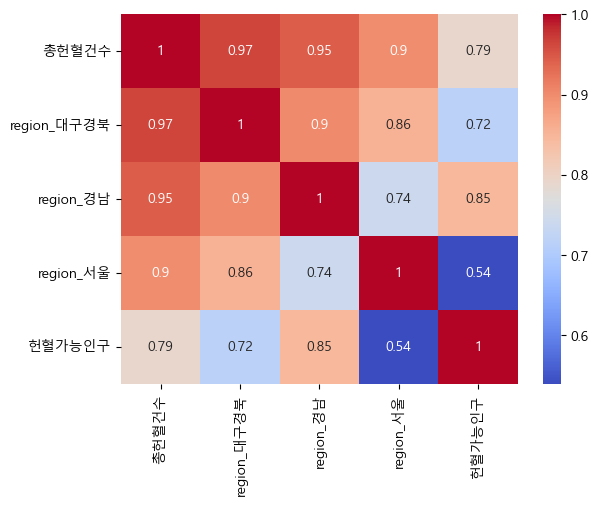

In [8]:
# ========================
# heatmap 
# ========================
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
# 높은 상관관계의 컬럼확인
corr = merged.corr(numeric_only=True)

corr_target = corr['총헌혈건수'].sort_values(
    ascending=False
)

print(corr_target.head(10))

# 상위만 heatmap

top_cols = [
    '총헌혈건수',
    'region_대구경북',      
    'region_경남',       
    'region_서울',                
    '헌혈가능인구',         
       
]

sns.heatmap(
    merged[top_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

# 서울, 대구·경북, 경남 지역의 헌혈량이 총헌혈건수와 높은 양의 상관관계를 보였다
# 하지만 시계열 데이터 특성상 다른 원인존재가능성이있음 (서울인구규모) -> 인구많은지역 집중관리
# 지역별 헌혈 참여 규모 차이가 전체 헌혈량에 영향을 줄 가능성을 확인 --> 지역맞춤캠페인()

In [9]:
# ==========================
# Merge정보
# ==========================
merged.columns
merged.shape

# 240개 행(row)
# 34개 컬럼(column)
# merged['년도'].nunique()
# merged[['년도']].drop_duplicates()

# 일반숫자 표기
pd.options.display.float_format = '{:,.0f}'.format
merged['총헌혈건수'].describe()
# 년도 기준으로 데이터를 병합하였으며, month 데이터의 월 정보를 유지하여 총 240개의 월 단위 시계열 데이터를 구성하였음

count         240
mean    2,680,116
std       259,886
min     2,087,762
25%     2,595,816
50%     2,693,550
75%     2,870,565
max     3,082,918
Name: 총헌혈건수, dtype: float64

In [10]:
# 문제생성

# 정렬
merged = merged.sort_values(
    ['년도', '월']
)


# targets
y = merged['총헌혈건수']

# feature
X = merged.drop(columns=['총헌혈건수'])


# 시계열 데이터분리
#전체 데이터의 80% 위치 계산
split_idx = int(len(merged) * 0.8)

# 시계열 데이터의 시간 순서를 유지하기 위해
#처음부터 80%까지를 학습용 feature 데이터로 사용
X_train = X.iloc[:split_idx]
# 20%를 테스트용 feature 데이터로 사용
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [11]:
# LinearRegression 모델생성
import numpy as np
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
# print('pred_lr:',pred_lr)
# 평가

mae_lr = mean_absolute_error(y_test, pred_lr)
mse_lr = mean_squared_error(y_test, pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, pred_lr)
train_score = lr.score(X_train,y_train)

print('train_score :', train_score)
print('MAE :', mae_lr)
print('MSE :', mse_lr)
print('RMSE :', rmse_lr)
print('R2 :', r2_lr)

train_score : 1.0
MAE : 15032.512998220578
MSE : 280566575.3829782
RMSE : 16750.121652781458
R2 : 0.9718924853520228


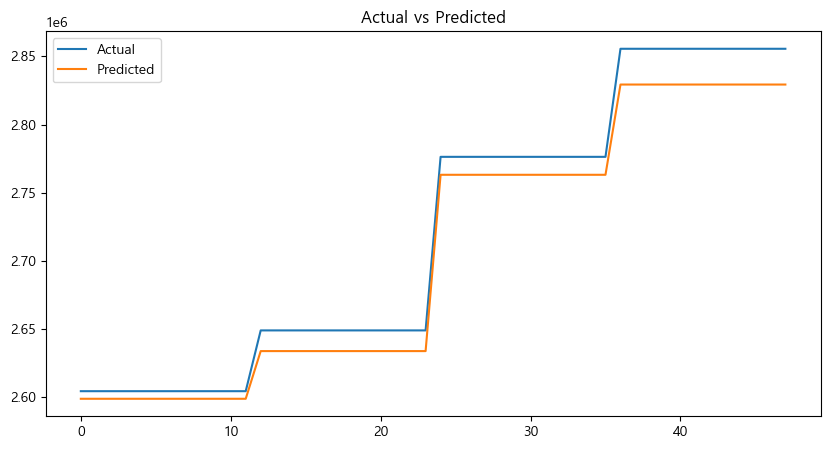

In [12]:
train_score = lr.score(X_train,y_train)
train_score


import matplotlib.pyplot as plt

# ====================================
# 실제 데이터와 예측데이터 그래프(년도)
# ====================================

# 예측값 생성
y_pred =lr.predict(X_test)

# 그래프
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    y_pred,
    label='Predicted'
)

plt.legend()

plt.title('Actual vs Predicted')

plt.show()

# linear 모델 평가 결과

> MAE : 15032.5129896122

> MSE : 280566575.10398763

> RMSE : 16750.12164445344

> R2 : 0.9718924853799723

> Train_score : 1.0

# 데이터 특성이 비교적 선형적이므로 LinearRegression이 가장 높은 성능을 보임
# !-- Train Score와 Test Score 모두 높은 성능을 보였지만 적은데이터양으로 과적합 -> lasso
# 데이터기반 예측 가능성 확인


In [13]:
# RandomForest 모델생성

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

# 평가

mae_rf = mean_absolute_error(y_test, pred_rf)
mse_rf = mean_squared_error(y_test, pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, pred_rf)

print('MAE_RF :', mae_rf)
print('MSE_RF :', mse_rf)
print('RMSE_RF :', rmse_rf)
print('R2_RF :', r2_rf)

# RANDOMFOREST 성능이 더 떨어짐

MAE_RF : 57735.392500000075
MSE_RF : 4125677100.00884
RMSE_RF : 64231.433893451576
R2_RF : 0.5866844460605044


# RandomForest 모델평가
> MAE_RF : 66398.1150000001

>MSE_RF : 4676305750.797963

>RMSE_RF : 68383.51958475055

>R2_RF : 0.5315217708682611

단순한 선형 데이터를 복잡하게 학습
낮은 R2값을 보임

In [14]:
# =========================
# 모델 성능 비교 데이터프레임
# =========================

score_df = pd.DataFrame({

    '모델': [
        'LinearRegression',
        'RandomForest'
    ],

    'R2': [
        r2_lr,
        r2_rf
    ],

    'RMSE': [
        rmse_lr,
        rmse_rf
    ],

    'MAE': [
        mae_lr,
        mae_rf
    ]

})

# 출력
print(score_df)



                 모델  R2   RMSE    MAE
0  LinearRegression   1 16,750 15,033
1      RandomForest   1 64,231 57,735


# Lasso (변수규제 및 과적합방지)

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# =========================
# Lasso alpha 파라미터 조정
# =========================
from sklearn.preprocessing import StandardScaler
# =========================
# 스케일러 생성
# =========================
scaler = StandardScaler()

# =========================
# 학습 데이터 스케일링
# =========================
X_train_scaled = scaler.fit_transform(
    X_train)
# =========================
# 테스트 데이터 스케일링
# =========================
X_test_scaled = scaler.transform(
    X_test)


alpha_list = [0.01, 0.1, 1, 10]

for alpha in alpha_list:

    lasso = Lasso(alpha=alpha)

    lasso.fit(X_train_scaled, y_train)

    train_score = lasso.score(X_train_scaled, y_train)
    test_score = lasso.score(X_test_scaled, y_test)

    print(f'alpha : {alpha}')
    print(f'Train Score : {train_score}')
    print(f'Test Score : {test_score}')
    print('-' * 30)

alpha : 0.01
Train Score : 0.9999968909111304
Test Score : 0.6183608247269244
------------------------------
alpha : 0.1
Train Score : 0.9999968722037985
Test Score : 0.6203645221988785
------------------------------
alpha : 1
Train Score : 0.9999969126969107
Test Score : 0.6397363007056073
------------------------------
alpha : 10
Train Score : 0.999998726559984
Test Score : 0.8915660435316914
------------------------------


In [ ]:
# Lasso 회귀 적용 결과 일부 alpha 값에서 Train/Test 성능 차이가 크게 나타나 과적합 가능성을 확인
# 랜덤 포레스트는 성능이 안 나오고 라쏘는 점수가 떨어졌다면, 트리 기반 모델 고성능모델 XGBoost


# GridSEARCH

In [22]:
import numpy as np
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 0. 시계열 순서를 보장하는 교차 검증 정의 (모든 모델 공통 사용)
tscv = TimeSeriesSplit(n_splits=3)

print("============ [1단계] 개별 모델 GridSearchCV 시작 ============\n")

# ==========================================
# ① Ridge 그리드 서치
# ==========================================
ridge_param = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 50.0]}
ridge_grid = GridSearchCV(Ridge(random_state=42), ridge_param, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
ridge_grid.fit(X_train_scaled, y_train)
best_ridge = ridge_grid.best_estimator_
print(f"✅ Ridge 최적 파라미터: {ridge_grid.best_params_}")

# ==========================================
# ② Lasso 그리드 서치
# ==========================================
# 단독 10에서 좋은 성능이 나왔으므로 10 전후를 세밀하게 탐색합니다.
lasso_param = {'alpha': [0.1, 1.0, 5.0, 10.0, 20.0, 50.0]}
lasso_grid = GridSearchCV(Lasso(random_state=42, max_iter=10000), lasso_param, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
lasso_grid.fit(X_train_scaled, y_train)
best_lasso = lasso_grid.best_estimator_
print(f"✅ Lasso 최적 파라미터: {lasso_grid.best_params_}")

# ==========================================
# ③ XGBoost 그리드 서치
# ==========================================
# 시계열 과적합을 막기 위해 깊이(max_depth)와 데이터 샘플링(subsample) 위주로 탐색합니다.
xgb_param = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 0.9]
}
xgb_grid = GridSearchCV(XGBRegressor(random_state=42, n_jobs=-1), xgb_param, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)
best_xgb = xgb_grid.best_estimator_
print(f"✅ XGBoost 최적 파라미터: {xgb_grid.best_params_}")


print("\n============ [2단계] 최적화된 모델 융합 및 최종 Voting 평가 ============\n")

# ==========================================
# ④ 최종 VotingRegressor 정의 및 학습
# ==========================================
final_voting = VotingRegressor(
    estimators=[
        ('ridge', best_ridge),
        ('lasso', best_lasso),
        ('xgb', best_xgb)
    ],
    n_jobs=-1
)

# 튜닝된 집단지성 모델 학습
final_voting.fit(X_train_scaled, y_train)

# 테스트 데이터 예측
y_final_pred = final_voting.predict(X_test_scaled)

# 성능 평가 지표 계산
final_r2 = r2_score(y_test, y_final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))
final_mae = mean_absolute_error(y_test, y_final_pred)

print("🏆 ===== 최종 그리드 서치 반영 Voting 결과 =====")
print(f"최종 Voting R² Score (설명력): {final_r2:.4f}")
print(f"최종 Voting RMSE (평균 제곱근 오차): {final_rmse:.2f}")
print(f"최종 Voting MAE (평균 절대 오차): {final_mae:.2f}")

============ [1단계] 개별 모델 GridSearchCV 시작 ============

✅ Ridge 최적 파라미터: {'alpha': 0.001}
✅ Lasso 최적 파라미터: {'alpha': 1.0}
✅ XGBoost 최적 파라미터: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 150, 'subsample': 0.7}

============ [2단계] 최적화된 모델 융합 및 최종 Voting 평가 ============

🏆 ===== 최종 그리드 서치 반영 Voting 결과 =====
최종 Voting R² Score (설명력): 0.8462
최종 Voting RMSE (평균 제곱근 오차): 39185.93
최종 Voting MAE (평균 절대 오차): 33979.32


In [21]:
import numpy as np
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ==========================================
# 1. 검증을 통해 확인된 최적의 개별 모델 정의
# ==========================================

# ① 그리드 서치로 찾은 최적의 릿지 (alpha=0.001)
best_ridge = Ridge(alpha=0.001, random_state=42)

# ② 단독 모델로 성능이 증명된 최적의 라쏘 (alpha=10)
best_lasso = Lasso(alpha=10, random_state=42)

# ③ 과적합을 방지하고 잔차를 잡아줄 XGBoost
best_xgb = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=4, 
    random_state=42, 
    n_jobs=-1
)

# ==========================================
# 2. 3개 모델을 융합한 VotingRegressor 정의
# ==========================================
# 라쏘의 성능이 워낙 압도적이므로, 라쏘와 기둥이 되는 릿지에 무게감을 더 실어주거나
# 기본 균등 분배([0.33, 0.33, 0.33])로 시작할 수 있습니다. 여기서는 균등하게 묶었습니다.
final_voting = VotingRegressor(
    estimators=[
        ('ridge', best_ridge),
        ('lasso', best_lasso),
        ('xgb', best_xgb)
    ],
    n_jobs=-1
)

# ==========================================
# 3. 최종 모델 학습 및 평가 (스케일링 데이터 반영)
# ==========================================
print("최적 파라미터 조합 기반 최종 Voting 모델 학습 시작...")
final_voting.fit(X_train_scaled, y_train)

# 예측
y_final_pred = final_voting.predict(X_test_scaled)

# 성능 평가 지표 계산
final_r2 = r2_score(y_test, y_final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))
final_mae = mean_absolute_error(y_test, y_final_pred)

print("\n===== 🏆 최적 파라미터 융합 Voting 결과 =====")
print(f"최종 Voting R² Score (설명력): {final_r2:.4f}")
print(f"최종 Voting RMSE (평균 제곱근 오차): {final_rmse:.2f}")
print(f"최종 Voting MAE (평균 절대 오차): {final_mae:.2f}")

최적 파라미터 조합 기반 최종 Voting 모델 학습 시작...

===== 🏆 최적 파라미터 융합 Voting 결과 =====
최종 Voting R² Score (설명력): 0.7714
최종 Voting RMSE (평균 제곱근 오차): 47766.67
최종 Voting MAE (평균 절대 오차): 38991.27


In [24]:
# Voting 모델 내부에 학습된 개별 모델들의 점수 확인하기
print("===== 🏆 개별 모델별 최종 Test R² Score =====\n")

for name, model in final_voting.named_estimators_.items():
    # 학습된 개별 모델로 예측값 생성
    pred = model.predict(X_test_scaled)
    # R2 점수 계산
    score = r2_score(y_test, pred)
    
    print(f"[{name}] 모델의 단독 Test R² 점수: {score:.4f}")

===== 🏆 개별 모델별 최종 Test R² Score =====

[ridge] 모델의 단독 Test R² 점수: 0.9893
[lasso] 모델의 단독 Test R² 점수: 0.6397
[xgb] 모델의 단독 Test R² 점수: -0.7372


In [26]:
# 1. 최적의 alpha로 Ridge 모델 다시 학습
best_ridge.fit(X_train_scaled, y_train)

# 2. Train 데이터와 Test 데이터 각각 예측값 생성
y_train_pred = best_ridge.predict(X_train_scaled)
y_test_pred = best_ridge.predict(X_test_scaled)

# 3. 양쪽 점수 비교 출력
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("===== 🔍 Ridge 모델 최종 점수 점검 =====")
print(f"Train R² Score (훈련 점수) : {train_r2:.4f}")
print(f"Test R² Score  (테스트 점수): {test_r2:.4f}")

===== 🔍 Ridge 모델 최종 점수 점검 =====
Train R² Score (훈련 점수) : 1.0000
Test R² Score  (테스트 점수): 0.9893


# 결론

최종 모델 선택: 현재 데이터셋에서는 최적의 하이퍼파라미터(alpha=0.001)로 튜닝된 **Ridge 단독 모델**을 최종 예측 모델로 채택

# 분석 흐름 

일반 선형회귀의 과적합을 막기 위해 릿지와 라쏘를 도입했고, 시계열의 복잡한 패턴을 잡기 위해 XGBoost와의 Voting 앙상블까지 폭넓게 실험했다
실험 결과 우리 데이터는 변수 간의 선형적 트렌드가 매우 뚜렷하여 **Ridge 단독 모델이 가장 압도적인 성능(98.93%)**을 보였기에 이를 최종 모델로 확정했다

추후에 데이터가 더 수집된다면 과적합은 자연스럽게 해결될 것이며, 그때는 선형 모델(Ridge)뿐만 아니라 복잡한 트리 모델(XGBoost)까지 도입해 훨씬 더 강력하고 안전한 모델을 만드실 수 있을 것 같습니다